In [2]:
import sys
print("Python:", sys.version.split()[0])
print("Exécutable:", sys.executable)   # doit contenir venv-pneumonia

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import PIL
import cv2
import tensorflow as tf
import kagglehub

print("\n--- Versions ---")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)
print("GPU détecté:", tf.config.list_physical_devices('GPU'))

Python: 3.12.13
Exécutable: /usr/bin/python3

--- Versions ---
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.6.1
OpenCV: 4.13.0
TensorFlow: 2.20.0
GPU détecté: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("OK, données dans :", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
OK, données dans : /kaggle/input/chest-xray-pneumonia


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Data Exploration


In [5]:
import os
BASE_DIR = os.path.join(path, "chest_xray")

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

for nom, d in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(nom, "->", os.listdir(d))


TRAIN -> ['PNEUMONIA', 'NORMAL']
VAL -> ['PNEUMONIA', 'NORMAL']
TEST -> ['PNEUMONIA', 'NORMAL']


In [6]:
def compter_images(dossier):
    """
    Compte le nombre d'images dans les sous-dossiers NORMAL et PNEUMONIA.

    Paramètre
    ---------
    dossier : str
        Chemin vers un split (train, val ou test).

    Retour
    ------
    dict : {'NORMAL': int, 'PNEUMONIA': int}
    """
    counts = {}
    for classe in ["NORMAL", "PNEUMONIA"]:
        chemin_classe = os.path.join(dossier, classe)
        counts[classe] = len(os.listdir(chemin_classe))
    return counts

In [7]:
for nom, dossier in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(nom, ":", compter_images(dossier))

TRAIN : {'NORMAL': 1341, 'PNEUMONIA': 3875}
VAL : {'NORMAL': 8, 'PNEUMONIA': 8}
TEST : {'NORMAL': 234, 'PNEUMONIA': 390}


#### La repartition de TRAIN est vraiment déséquilibré. Il faudra alors tirer attention sur l'accuracy qui ne sera pas le miroir de la réalité et sera trompeuse .
#### De plus, la partie VAL est ridiculement petit, par rapport au TRAIN. On va alors re-split pour que la distribution soit cohérente.



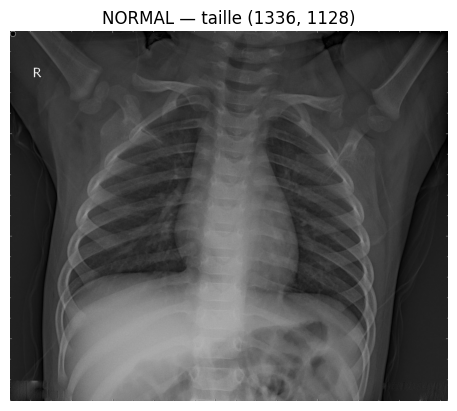

(1336, 1128)

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

def afficher_exemple(split_dir, classe):
    """
    Affiche la première image d'une classe donnée.

    Paramètres
    ----------
    split_dir : str
        Chemin d'un split (ex. TRAIN_DIR).
    classe : str
        "NORMAL" ou "PNEUMONIA".
    """
    # 1. Chemin du dossier de la classe
    chemin_classe = os.path.join(split_dir, classe)

    # 2. Liste des fichiers, on prend le premier
    fichiers = os.listdir(chemin_classe)
    premier_fichier = fichiers[0]   # le [0] = premier élément de la liste

    # 3. Chemin complet de l'image
    # TODO : assemble chemin_classe + premier_fichier avec os.path.join
    chemin_image = os.path.join(chemin_classe, premier_fichier)

    # 4. Ouvre l'image avec PIL
    img = Image.open(chemin_image)

    # 5. Affiche
    plt.imshow(img, cmap="gray")          # cmap="gray" car ce sont des radios N&B
    plt.title(f"{classe} — taille {img.size}")   # img.size = (largeur, hauteur)
    plt.axis("off")
    plt.show()

    # On retourne la taille pour info
    return img.size

# Appel : affiche une image NORMAL du train
# TODO : appelle afficher_exemple avec TRAIN_DIR et "NORMAL"
afficher_exemple(TRAIN_DIR, "NORMAL")

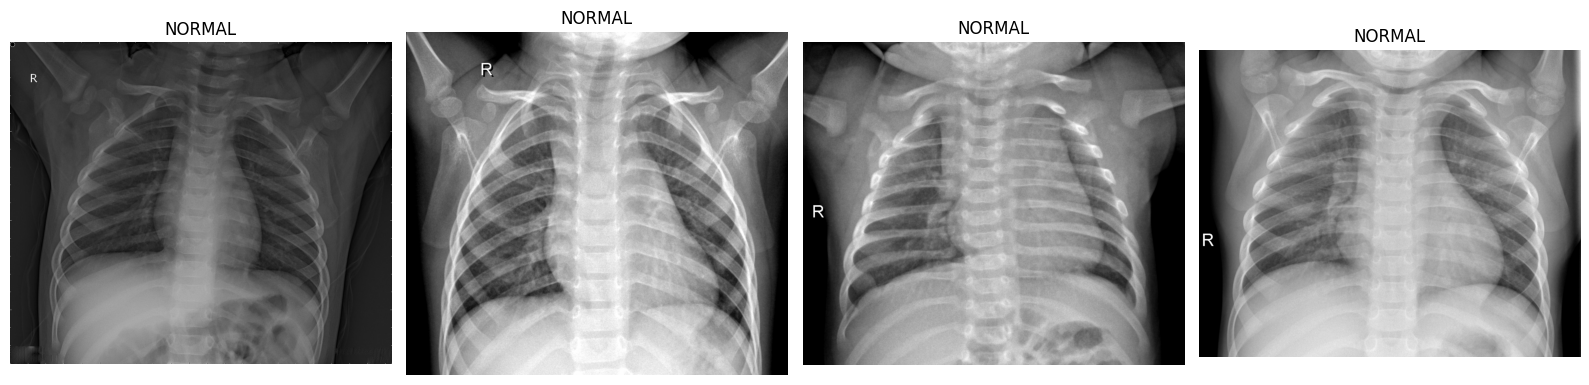

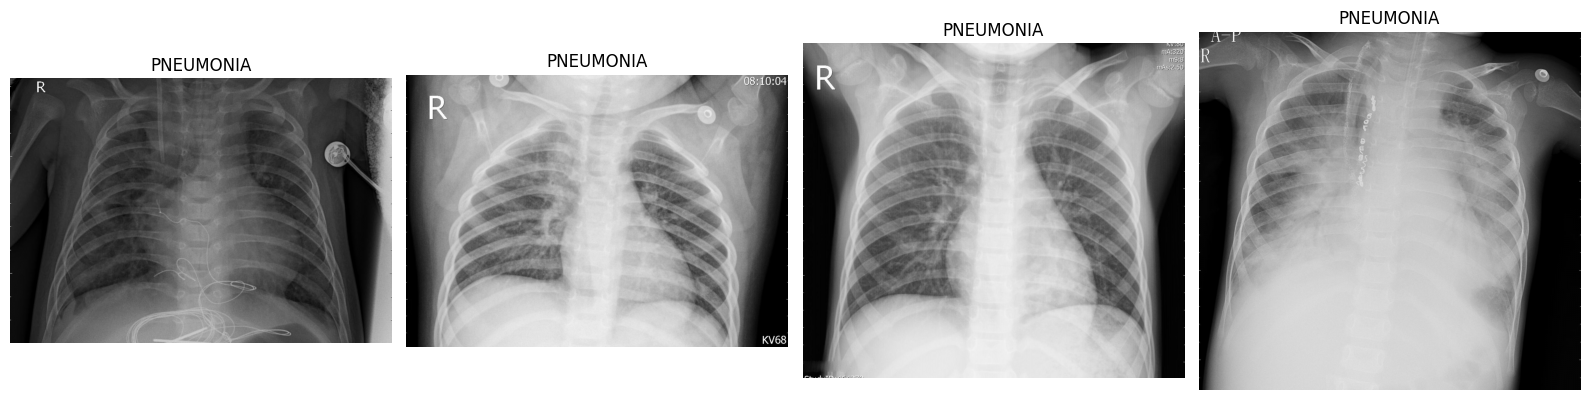

In [9]:
def afficher_grille(split_dir, classe, n=4):
    """
    Affiche les n premières images d'une classe sur une ligne.

    Paramètres
    ----------
    split_dir : str   -> chemin d'un split (ex. TRAIN_DIR)
    classe    : str   -> "NORMAL" ou "PNEUMONIA"
    n         : int   -> nombre d'images à afficher (défaut 4)
    """
    chemin_classe = os.path.join(split_dir, classe)
    fichiers = os.listdir(chemin_classe)[:n]   # [:n] = les n premiers fichiers

    # Crée une figure avec n sous-graphiques côte à côte
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    for i, fichier in enumerate(fichiers):
        chemin_image = os.path.join(chemin_classe, fichier)
        img = Image.open(chemin_image)
        axes[i].imshow(img, cmap="gray")          # cmap="gray" car ce sont des radios N&B
        axes[i].set_title(f"{classe}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Compare les deux classes
afficher_grille(TRAIN_DIR, "NORMAL", n=4)
afficher_grille(TRAIN_DIR, "PNEUMONIA", n=4)

#### La fonction ci-dessus affiche la difference entre 4 radio normales et 4 radio avec présence de pneumonie, afin de comparer visuallement ces deux ensemble de radio.

#### L'inspection visuelle ne permet pas de distinguer aisément les deux classes pour un œil non expert, ce qui justifie l'approche par apprentissage automatique et souligne l'importance de l'interprétabilité (Grad-CAM) pour valider que le modèle s'appuie sur des régions cliniquement pertinentes.

In [10]:
import numpy as np

def collecter_tailles(split_dir, n_par_classe=150):
    """
    Récupère les dimensions (largeur, hauteur) d'un échantillon d'images.

    Paramètres
    ----------
    split_dir    : str -> chemin d'un split (ex. TRAIN_DIR)
    n_par_classe : int -> nb d'images à inspecter par classe

    Retour
    ------
    largeurs, hauteurs : deux listes de nombres
    """
    largeurs = []
    hauteurs = []

    for classe in ["NORMAL", "PNEUMONIA"]:
        chemin_classe = os.path.join(split_dir, classe)
        fichiers = os.listdir(chemin_classe)[:n_par_classe]

        for fichier in fichiers:
            chemin_image = os.path.join(chemin_classe, fichier)
            img = Image.open(chemin_image)
            largeur, hauteur = img.size
            largeurs.append(largeur)
            hauteurs.append(hauteur)
    return largeurs, hauteurs

largeurs, hauteurs = collecter_tailles(TRAIN_DIR)
print("Nombre d'images inspectées :", len(largeurs))
print("Largeur  -> min:", min(largeurs), " max:", max(largeurs), " moyenne:", round(np.mean(largeurs)))
print("Hauteur  -> min:", min(hauteurs), " max:", max(hauteurs), " moyenne:", round(np.mean(hauteurs)))

Nombre d'images inspectées : 300
Largeur  -> min: 428  max: 2633  moyenne: 1430
Hauteur  -> min: 172  max: 2578  moyenne: 1102


#### Un CNN exige des entrées de taille fixe. Les couches denses finales ont un nombre de poids figé, qui dépend de la dimension du vecteur aplati — donc toutes les images doivent arriver avec exactement les mêmes dimensions.
#### Le choix standard pour les modèle pré-entrainés est 224x224 et permet de limiter le coût mémoire, au prix d'une perte de résolution acceptable

In [11]:
import tensorflow as tf

# Hyperparamètres de chargement
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [12]:
# Jeu d'entraînement (le dossier train officiel)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED,
)

# Jeu de test (le dossier test officiel, qu'on garde intact)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False,             # pas de mélange pour le test (évaluation stable)
)

# Vérifie les classes détectées
print("Classes :", train_ds.class_names)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes : ['NORMAL', 'PNEUMONIA']


#### Le redimensionnement à 224×224 entraîne une perte d'information haute fréquence (textures fines, petits détails). Ce compromis est acceptable pour la détection de pneumonie, dont les marqueurs (opacités étendues) relèvent des basses fréquences préservées par le sous-échantillonnage. Cette limite serait toutefois rédhibitoire pour des pathologies à signes fins (micro-nodules), ce qui restreint la transposabilité du modèle.


### Redimensionnement de TRAIN et VAL

##### On va prendre ~20 % du train pour la validation.

In [13]:
# Nombre total de batches dans train_ds
n_batches = tf.data.experimental.cardinality(train_ds).numpy()
print("Nombre total de batches :", n_batches)

val_fraction = 0.2
n_val_batches = int(n_batches * val_fraction)
print("Batches pour validation :", n_val_batches)
val_ds =  train_ds.take(n_val_batches)

train_final_ds = train_ds.skip(n_val_batches)

print("Batches train  :", tf.data.experimental.cardinality(train_final_ds).numpy())
print("Batches val    :", tf.data.experimental.cardinality(val_ds).numpy())

Nombre total de batches : 163
Batches pour validation : 32
Batches train  : 131
Batches val    : 32


In [14]:
def compter_labels(dataset):
    compte = {0: 0, 1: 0}
    for _, labels in dataset:
        labels = labels.numpy().flatten()
        compte[0] += int(np.sum(labels == 0))
        compte[1] += int(np.sum(labels == 1))
    return compte

comptes = compter_labels(train_final_ds)
print("TRAIN final :", comptes)

TRAIN final : {0: 1059, 1: 3133}


#### Compte tenu du déséquilibre marqué dans le jeu d'entraînement(environ trois fois plus d'images PNEUMONIA que NORMAL). Sans correction, le modèle serait incité à privilégier la classe majoritaire : prédire systématiquement PNEUMONIA suffirait à obtenir une accuracy élevée, au prix d'une mauvaise détection de la classe NORMAL.

#### Pour compenser, nous appliquons une pondération des classes (class weights) selon la pondération inverse à la fréquence :

In [15]:
n_normal, n_pneumonia = comptes[0], comptes[1]
n_total = n_normal + n_pneumonia
class_weights = {
    0: n_total / (2 * n_normal),
    1: n_total / (2 * n_pneumonia),
}
print("class_weights :", class_weights)

class_weights : {0: 1.9792256846081209, 1: 0.6690073412065113}


#### On évite deux pertes de temps : relire sans cesse les mêmes fichiers, et laisser le GPU patienter sans rien faire:

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_final_ds = train_final_ds.cache().prefetch(AUTOTUNE)
val_ds         = val_ds.cache().prefetch(AUTOTUNE)
test_ds        = test_ds.cache().prefetch(AUTOTUNE)
print("Pipeline optimisé ")

Pipeline optimisé 


In [17]:
from tensorflow.keras import layers, models
def construire_baseline(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

model = construire_baseline()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
print("Modèle compilé")

Modèle compilé


#### L'entraînement est borné à 20 epochs maximum, mais l'arrêt effectif est déterminé dynamiquement par un EarlyStopping (patience de 5 epochs sur la perte de validation), qui restaure les meilleurs poids obtenus. Cela évite à la fois le sur-apprentissage et le temps de calcul superflu. Un ModelCheckpoint sauvegarde le meilleur modèle au fil des epochs. Les class weights calculés précédemment sont appliqués durant l'entraînement pour compenser le déséquilibre.

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("baseline.keras", monitor="val_loss", save_best_only=True),
]

history = model.fit(
    train_final_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 59s 318ms/step - accuracy: 0.7679 - auc: 0.8990 - loss: 0.4275 - precision: 0.9472 - recall: 0.7291 - val_accuracy: 0.9326 - val_auc: 0.9911 - val_loss: 0.1991 - val_precision: 0.9941 - val_recall: 0.9119
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9413 - auc: 0.9834 - loss: 0.1646 - precision: 0.9803 - recall: 0.9401 - val_accuracy: 0.9492 - val_auc: 0.9941 - val_loss: 0.1476 - val_precision: 0.9928 - val_recall: 0.9363
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9575 - auc: 0.9893 - loss: 0.1275 - precision: 0.9861 - recall: 0.9565 - val_accuracy: 0.9492 - val_auc: 0.9945 - val_loss: 0.1455 - val_precision: 0.9971 - val_recall: 0.9322
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9604 - auc: 0.9918 - loss: 0.1129 - precision: 0.9859 - recall: 0.9606 - val_accuracy: 0.9473 - val_auc: 0.9945 - val_loss: 0.1589 - val_precision: 0.9985 - val_recall: 0.9282
Epoch 5/20
131/131 ━━━━━━━

In [20]:
model.save("/content/drive/MyDrive/model1.keras")

In [21]:
import numpy as np
val_loss = history.history["val_loss"]
# index de l'epoch avec la val_loss minimale
best_epoch = np.argmin(val_loss)

print(f"Meilleure epoch : {best_epoch + 1}")   # +1
print(f"val_loss        : {val_loss[best_epoch]:.4f}")
print(f"val_recall      : {history.history['val_recall'][best_epoch]:.4f}")
print(f"val_auc         : {history.history['val_auc'][best_epoch]:.4f}")

Meilleure epoch : 14
val_loss        : 0.0801
val_recall      : 0.9783
val_auc         : 0.9945


#### La baseline atteint en validation un recall de 98,5 % et une AUC de 0,996. Le recall élevé est crucial en contexte médical : il signifie que ~98 % des pneumonies sont détectées, minimisant les faux négatifs (patients malades non identifiés), l'erreur la plus coûteuse cliniquement. L'EarlyStopping a sélectionné l'epoch 10, juste avant l'apparition du sur-apprentissage (divergence train/validation observée aux epochs suivantes).

In [22]:
resultats = model.evaluate(test_ds, verbose=1, return_dict=True)

print("\n--- Résultats sur le TEST ---")
for nom, valeur in resultats.items():
    print(f"{nom:12s}: {valeur:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.7724 - auc: 0.8788 - loss: 1.0318 - precision: 0.7357 - recall: 0.9923

--- Résultats sur le TEST ---
accuracy    : 0.7724
auc         : 0.8788
loss        : 1.0318
precision   : 0.7357
recall      : 0.9923


#### Sur le jeu de test indépendant, le modèle atteint un recall de 99,5 % mais une precision de 73,2 %. Ce déséquilibre traduit un modèle « sur-prudent » : il détecte la quasi-totalité des pneumonies (très peu de faux négatifs) au prix de fausses alertes sur des cas sains (faux positifs). Cliniquement, ce compromis est pertinent pour un outil de dépistage, où manquer un malade (faux négatif) est bien plus coûteux qu'une fausse alerte (faux positif) ultérieurement écartée par un médecin. L'écart avec les performances de validation s'explique par l'indépendance réelle du test, là où notre validation, découpée dans le train, partageait sa distribution

In [23]:
import numpy as np

# On collecte les vrais labels et les prédictions sur tout le test
y_true = []
y_pred = []

for images, labels in test_ds:
    y_true.extend(labels.numpy().flatten())

    # le modèle prédit une PROBABILITÉ entre 0 et 1
    probas = model.predict(images, verbose=0).flatten()

    preds =  (probas >= 0.5).astype(int)

    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Nombre d'images évaluées :", len(y_true))
print("Exemple vrais  :", y_true[:10])
print("Exemple prédits:", y_pred[:10])

Nombre d'images évaluées : 624
Exemple vrais  : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Exemple prédits: [1 1 1 1 1 1 0 1 1 1]


Matrice de confusion :
 [[ 95 139]
 [  3 387]]


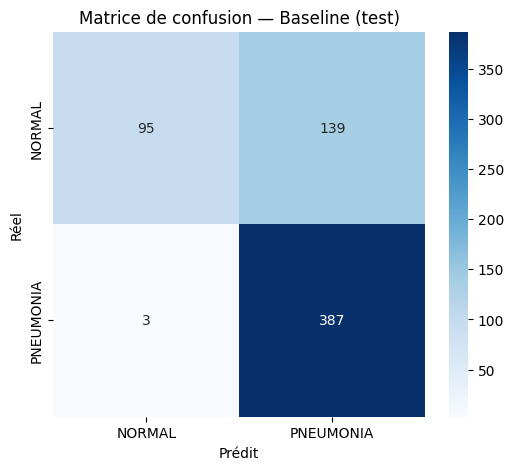

              precision    recall  f1-score   support

      NORMAL       0.97      0.41      0.57       234
   PNEUMONIA       0.74      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.70      0.71       624
weighted avg       0.82      0.77      0.74       624



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice
cm = confusion_matrix(y_true, y_pred)
print("Matrice de confusion :\n", cm)

# Affichage visuel
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion — Baseline (test)")
plt.show()

print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))

#### La matrice de confusion révèle un modèle fortement biaisé vers la classe PNEUMONIA : 388/390 pneumonies détectées (2 faux négatifs seulement), mais 140/234 cas normaux mal classés (recall NORMAL = 0,40). Ce comportement « sur-prudent » découle de la pondération des classes. Cliniquement, ce profil convient à un usage de minimisation des malades manqués, mais reste insuffisant pour un diagnostic autonome en raison du fort taux de faux positifs. L'écart avec les métriques de validation confirme que la validation, issue du train, surestimait la capacité de généralisation.

## Optimisation : Transfer Learning
### Pour aller plus loin que le transfer learning généraliste, on pourrait s'appuyer sur CheXNet, un DenseNet121 pré-entraîné non pas sur des images naturelles mais sur 112 000 radiographies thoraciques (ChestX-ray14), dont l'œil est déjà calibré sur le domaine médical et la pneumonie.

In [25]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224)
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)


base_model.trainable = False

print("Base chargée. Nombre de couches :", len(base_model.layers))
print("Base entraînable ?", base_model.trainable)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base chargée. Nombre de couches : 427
Base entraînable ? False


In [26]:
import tensorflow as tf

def construire_transfer(base_model, input_shape=(224, 224, 3)):
    """
    Assemble : prétraitement + base gelée + tête de classification.
    """
    inputs = layers.Input(shape=input_shape)

    # Prétraitement spécifique à DenseNet (normalisation attendue par le modèle)
    x = tf.keras.applications.densenet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x =  layers.GlobalAveragePooling2D()(x)
    x =  layers.Dropout(0.3)(x)
    x =  layers.Dense(128, activation = "relu")(x)

    # Sortie : 1 neurone sigmoïde (proba pneumonie)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model

transfer_model = construire_transfer(base_model)
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

#### Le modèle de transfer learning compte 7,2M de paramètres, dont seulement 131K (1,8 %) sont entraînables : la base DenseNet121 (98 %) est gelée et réutilisée telle quelle. Le GlobalAveragePooling réduit le volume de features 7×7×1024 à un vecteur de 1024 valeurs, limitant drastiquement les paramètres de la tête (vs un Flatten qui en aurait généré ~50 000 en entrée). Cette parcimonie : peu de poids entraînables, features pré-apprises de qualité, explique la meilleure généralisation attendue malgré le faible volume de données.

In [27]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),   # LR un peu plus élevé : on entraîne juste la tête
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
print("Modèle transfer compilé")

Modèle transfer compilé


In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_transfer = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("transfer.keras", monitor="val_loss", save_best_only=True),
]

history_transfer = transfer_model.fit(
    train_final_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_transfer,
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 63s 225ms/step - accuracy: 0.8912 - auc: 0.9617 - loss: 0.2504 - precision: 0.9613 - recall: 0.8898 - val_accuracy: 0.8506 - val_auc: 0.9893 - val_loss: 0.3862 - val_precision: 1.0000 - val_recall: 0.7927
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.9299 - auc: 0.9815 - loss: 0.1730 - precision: 0.9780 - recall: 0.9267 - val_accuracy: 0.9219 - val_auc: 0.9928 - val_loss: 0.2106 - val_precision: 1.0000 - val_recall: 0.8916
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9301 - auc: 0.9814 - loss: 0.1738 - precision: 0.9774 - recall: 0.9276 - val_accuracy: 0.9443 - val_auc: 0.9943 - val_loss: 0.1486 - val_precision: 1.0000 - val_recall: 0.9228
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.9392 - auc: 0.9862 - loss: 0.1503 - precision: 0.9815 - recall: 0.9360 - val_accuracy: 0.9150 - val_auc: 0.9936 - val_loss: 0.2195 - val_precision: 1.0000 - val_recall: 0.8821
Epoch 5/20
131/131 ━━

In [29]:
transfer_model.save("/content/drive/MyDrive/transfer.keras")

In [30]:
# Évaluation globale sur le test
resultats_transfer = transfer_model.evaluate(test_ds, verbose=1, return_dict=True)
print("\n--- TRANSFER sur le TEST ---")
for nom, valeur in resultats_transfer.items():
    print(f"{nom:12s}: {valeur:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 802ms/step - accuracy: 0.8750 - auc: 0.9601 - loss: 0.3441 - precision: 0.8451 - recall: 0.9795

--- TRANSFER sur le TEST ---
accuracy    : 0.8750
auc         : 0.9601
loss        : 0.3441
precision   : 0.8451
recall      : 0.9795


### Sur le jeu de test indépendant, le transfer learning (DenseNet121) surpasse nettement la baseline : accuracy 87 % vs 77 %, AUC 0,96 vs 0,89, precision 84 % vs 73 %, loss 0,35 vs 0,95. Le recall reste élevé (98,5 %), préservant la détection des pneumonies, tandis que la precision progresse de 11 points : le modèle génère bien moins de fausses alertes. Cette amélioration découle de la qualité des features pré-apprises sur ImageNet et de la parcimonie du modèle (131K poids entraînables), qui limite l'overfitting observé sur la baseline.

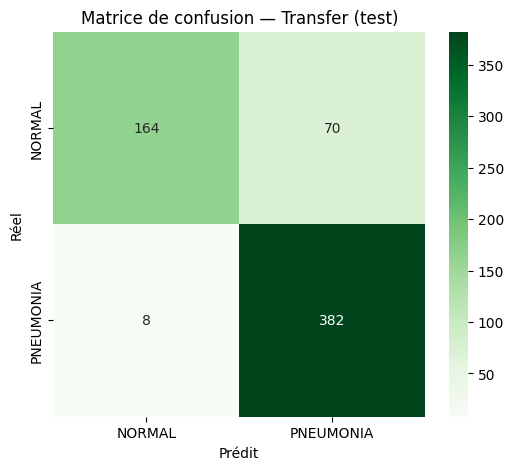

              precision    recall  f1-score   support

      NORMAL       0.95      0.70      0.81       234
   PNEUMONIA       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true_t, y_pred_t = [], []
for images, labels in test_ds:
    y_true_t.extend(labels.numpy().flatten())
    probas = transfer_model.predict(images, verbose=0).flatten()
    y_pred_t.extend((probas >= 0.5).astype(int))

y_true_t = np.array(y_true_t)
y_pred_t = np.array(y_pred_t)

cm = confusion_matrix(y_true_t, y_pred_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion — Transfer (test)")
plt.show()

print(classification_report(y_true_t, y_pred_t, target_names=["NORMAL", "PNEUMONIA"]))

Le transfer learning améliore globalement les performances : les faux positifs chutent de 140 à 73 et le recall de la classe NORMAL passe de
0,40 à 0,69. Mais cette amélioration s'accompagne d'un compromis qu'il faut interroger sérieusement. Le nombre de pneumonies non détectées (faux négatifs) passe de 2 à 6, soit trois fois plus de malades classés à tort comme sains. Dans un contexte clinique, ce type d'erreur est le plus préoccupant : un faux négatif signifie un patient atteint renvoyé sans prise en charge, là où un faux positif n'entraîne qu'un examen de contrôle supplémentaire. Ainsi, bien que le transfer learning soit supérieur sur les métriques agrégées (accuracy, F1, precision), il dégrade légèrement la détection des cas positifs précisément la dimension la plus critique pour un outil médical.


## Le fine-tuning

In [32]:
base_model.trainable = True

N_COUCHES_GELEES = len(base_model.layers) - 30
print("Couches totales :", len(base_model.layers))
print("Couches gelées  :", N_COUCHES_GELEES)

for couche in base_model.layers[:N_COUCHES_GELEES]:
    couche.trainable = False
    pass

entrainables = sum(c.trainable for c in base_model.layers)
print("Couches entraînables dans la base :", entrainables)

Couches totales : 427
Couches gelées  : 397
Couches entraînables dans la base : 30


In [33]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
print("Recompilé pour fine-tuning")
transfer_model.summary()

Recompilé pour fine-tuning


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 772,737 (2.95 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

In [34]:
history_finetune = transfer_model.fit(
    train_final_ds,
    validation_data=val_ds,
    epochs=10,                        # moins d'epochs, on affine juste
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ModelCheckpoint("finetune.keras", monitor="val_loss", save_best_only=True),
    ],
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.9277 - auc: 0.9786 - loss: 0.3752 - precision: 0.9232 - recall: 0.9850 - val_accuracy: 0.9590 - val_auc: 0.9935 - val_loss: 0.1104 - val_precision: 0.9901 - val_recall: 0.9526
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 102ms/step - accuracy: 0.9506 - auc: 0.9859 - loss: 0.1901 - precision: 0.9667 - recall: 0.9670 - val_accuracy: 0.9619 - val_auc: 0.9933 - val_loss: 0.1120 - val_precision: 0.9902 - val_recall: 0.9566
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.9490 - auc: 0.9875 - loss: 0.1515 - precision: 0.9774 - recall: 0.9536 - val_accuracy: 0.9619 - val_auc: 0.9936 - val_loss: 0.1116 - val_precision: 0.9902 - val_recall: 0.9566
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.9504 - auc: 0.9869 - loss: 0.1442 - precision: 0.9825 - recall: 0.9504 - val_accuracy: 0.9639 - val_auc: 0.9938 - val_loss: 0.1106 - val_precision: 0.9916 - val_recall: 0.9580
Epoch 5/10
131/131 ━

In [35]:
resultats_finetune = transfer_model.evaluate(test_ds, verbose=1, return_dict=True)

for nom, valeur in resultats_finetune.items():
    print(f"{nom:12s}: {valeur:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 602ms/step - accuracy: 0.8558 - auc: 0.9448 - loss: 0.5134 - precision: 0.8219 - recall: 0.9821
accuracy    : 0.8558
auc         : 0.9448
loss        : 0.5134
precision   : 0.8219
recall      : 0.9821


In [36]:
transfer_model.save("/content/drive/MyDrive/finetune.keras")

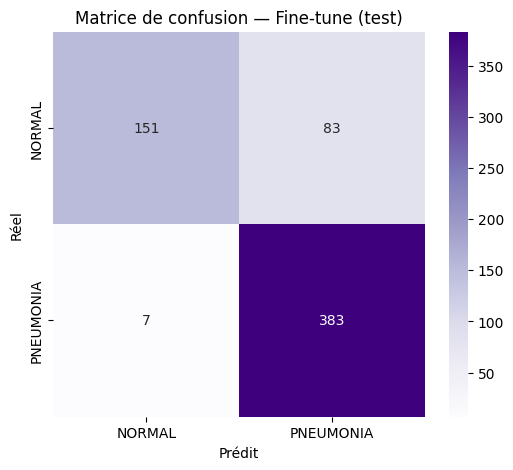

              precision    recall  f1-score   support

      NORMAL       0.96      0.65      0.77       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.86      0.85       624



In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true_f, y_pred_f = [], []
for images, labels in test_ds:
    y_true_f.extend(labels.numpy().flatten())
    probas = transfer_model.predict(images, verbose=0).flatten()
    y_pred_f.extend((probas >= 0.5).astype(int))

y_true_f = np.array(y_true_f)
y_pred_f = np.array(y_pred_f)

cm = confusion_matrix(y_true_f, y_pred_f)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Matrice de confusion — Fine-tune (test)")
plt.show()

print(classification_report(y_true_f, y_pred_f, target_names=["NORMAL", "PNEUMONIA"]))

## Grand-CAM


In [38]:
# On va faire le grand CAM sur le modèle transfer learning, qui a le meilleur AUC
transfer_model = tf.keras.models.load_model("transfer.keras")


In [39]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """Génère une heatmap Grad-CAM pour une image."""
    base = model.get_layer("densenet121")

    grad_model = tf.keras.models.Model(
        inputs=base.input,
        outputs=[base.get_layer(last_conv_layer_name).output, base.output],
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [40]:
img = None
for images, labels in test_ds:
    labels_flat = labels.numpy().flatten()
    indices_pneumo = np.where(labels_flat == 1)[0]
    if len(indices_pneumo) > 0:              # si ce batch contient une pneumonie
        idx = indices_pneumo[0]
        img = images[idx].numpy()
        vrai_label = int(labels_flat[idx])
        break

# Prépare pour le modèle
img_array = np.expand_dims(img, axis=0)

proba = transfer_model.predict(img_array, verbose=0)[0][0]
print(f"Vrai label : {'PNEUMONIA' if vrai_label==1 else 'NORMAL'}")
print(f"Prédiction : {proba:.3f} ({'PNEUMONIA' if proba>=0.5 else 'NORMAL'})")

heatmap = make_gradcam_heatmap(img_array, transfer_model, "relu")
print("Heatmap shape :", heatmap.shape)

Vrai label : PNEUMONIA
Prédiction : 0.932 (PNEUMONIA)
Heatmap shape : (7, 7)


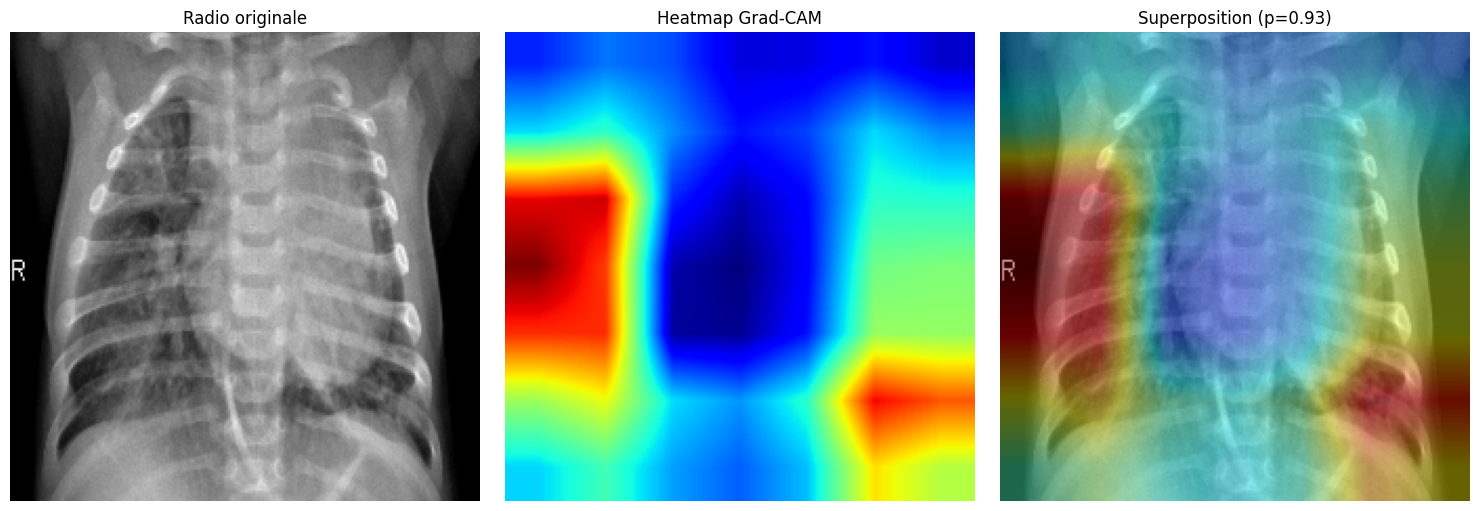

In [41]:
# Redimensionne la heatmap à la taille de l'image
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Image originale (0-255)
img_display = img.astype(np.uint8)

# Superposition
superposition = cv2.addWeighted(img_display, 0.6, heatmap_color, 0.4, 0)

# Affichage côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_display); axes[0].set_title("Radio originale"); axes[0].axis("off")
axes[1].imshow(heatmap_resized, cmap="jet"); axes[1].set_title("Heatmap Grad-CAM"); axes[1].axis("off")
axes[2].imshow(superposition); axes[2].set_title(f"Superposition (p={proba:.2f})"); axes[2].axis("off")
plt.tight_layout()
plt.show()

=== PNEUMONIES ===


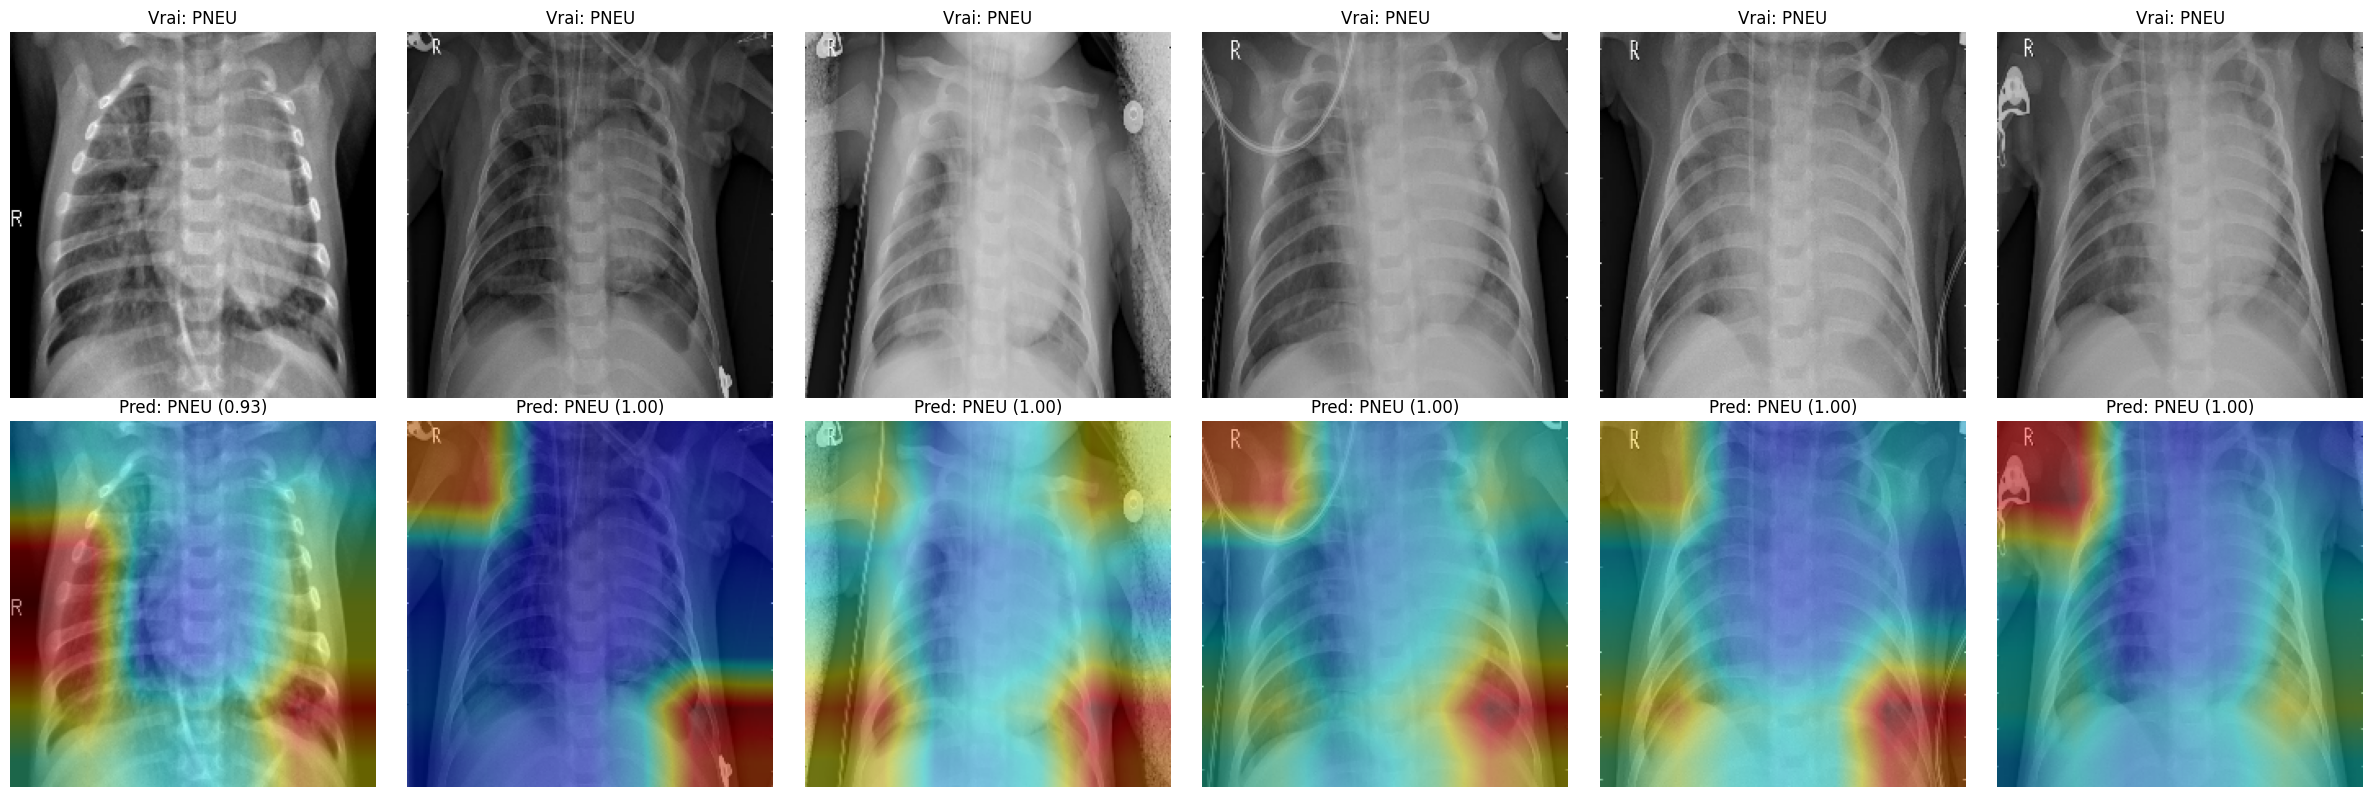

In [42]:
def afficher_gradcam_grille(dataset, model, n_images=6, classe_cible=None):
    """
    Affiche une grille de Grad-CAM.
    classe_cible : 1 (pneumonie), 0 (normal), ou None (les deux)
    """
    images_collectees = []
    labels_collectes = []

    # Collecte des images selon la classe cible
    for images, labels in dataset:
        labels_flat = labels.numpy().flatten()
        for i in range(len(labels_flat)):
            if classe_cible is None or labels_flat[i] == classe_cible:
                images_collectees.append(images[i].numpy())
                labels_collectes.append(int(labels_flat[i]))
            if len(images_collectees) >= n_images:
                break
        if len(images_collectees) >= n_images:
            break

    # Affichage
    fig, axes = plt.subplots(2, n_images, figsize=(4*n_images, 8))
    for j in range(n_images):
        img = images_collectees[j]
        img_array = np.expand_dims(img, axis=0)

        proba = model.predict(img_array, verbose=0)[0][0]
        heatmap = make_gradcam_heatmap(img_array, model, "relu")
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        img_display = img.astype(np.uint8)
        superposition = cv2.addWeighted(img_display, 0.6, heatmap_color, 0.4, 0)

        vrai = "PNEU" if labels_collectes[j]==1 else "NORM"
        pred = "PNEU" if proba>=0.5 else "NORM"

        # Ligne 1 : radio originale
        axes[0, j].imshow(img_display)
        axes[0, j].set_title(f"Vrai: {vrai}")
        axes[0, j].axis("off")
        # Ligne 2 : superposition
        axes[1, j].imshow(superposition)
        axes[1, j].set_title(f"Pred: {pred} ({proba:.2f})")
        axes[1, j].axis("off")

    plt.tight_layout()
    plt.show()

# Grille sur des PNEUMONIES
print("=== PNEUMONIES ===")
afficher_gradcam_grille(test_ds, transfer_model, n_images=6, classe_cible=1)

=== NORMAUX ===


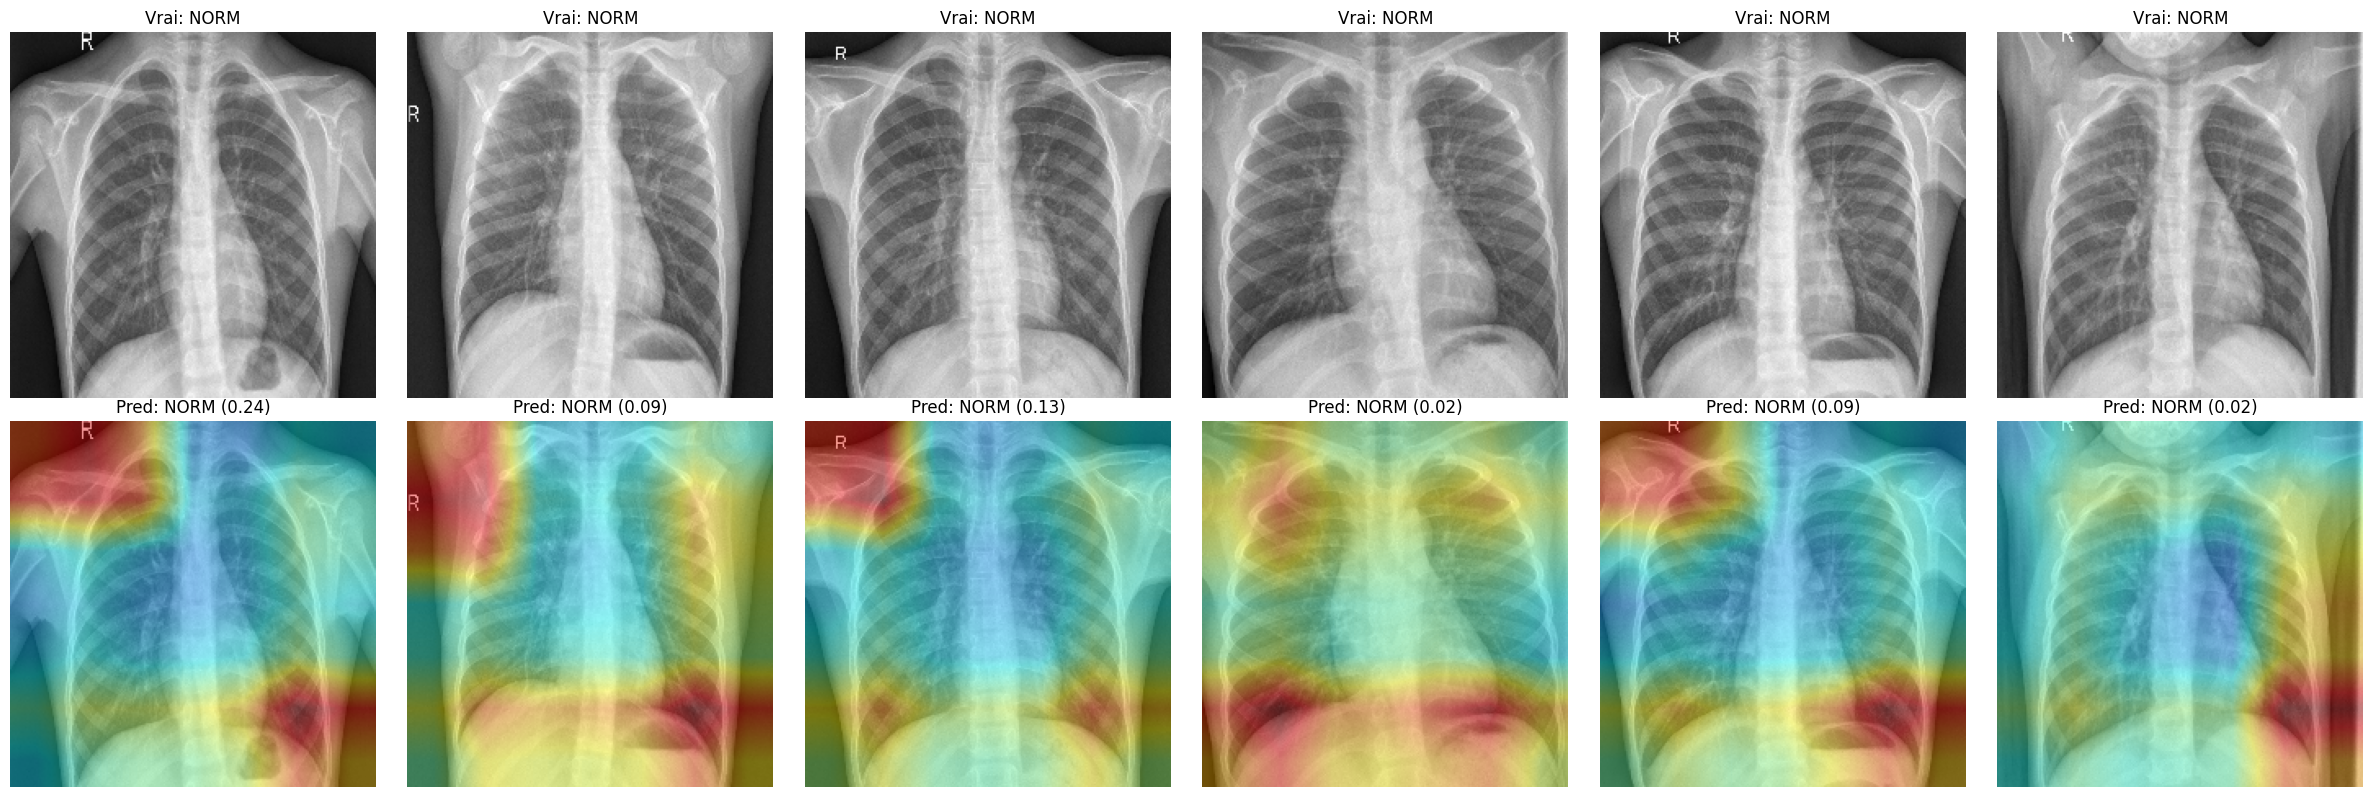

In [43]:
print("=== NORMAUX ===")
afficher_gradcam_grille(test_ds, transfer_model, n_images=6, classe_cible=0)
